# DXY Criticality — Model vs 7-Day Rolling SD

Same base CSV as `eval_signal_v2.ipynb` (`data/results_cutoff_mapped.csv`),
same Aug 2025 → Mar 2026 window.

**Question:** how does the model's `criticality_level` flag compare against
a more principled, time-aware ground truth — namely, *was the 15-minute DXY
move that followed an article larger than the trailing 7-day SD of 15-minute
moves at that article's timestamp?*

`eval_signal_v2.ipynb` benchmarks the model against a single global SD computed
across the whole evaluation window. That has two problems:
1. It leaks future information into the SD threshold for early articles.
2. It treats a calm-regime move and a turbulent-regime move identically.

A trailing 7-day rolling SD fixes both — each article is judged against the
volatility regime that was actually observable when it was published.


In [1]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings("ignore")

from label_true_criticality import load_dxy, trailing_sd_at

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":      True,
    "grid.alpha":     0.3,
    "grid.linestyle": "--",
    "font.size":      11,
})

TEAL  = "#1D9E75"
CORAL = "#D85A30"
GRAY  = "#888780"
BLUE  = "#378ADD"
AMBER = "#BA7517"

ROLLING_DAYS = 7
DXY_PATH     = "data/dxy_intraday_min.csv"
BASE_CSV     = "data/results_cutoff_mapped.csv"

df = pd.read_csv(BASE_CSV)
df["dt"] = pd.to_datetime(df["article_published_utc"], utc=True, errors="coerce")

# Mirror eval_signal_v2: drop Mar/Apr/May 2025 (out-of-sample period)
apr_may = (df["dt"].dt.year == 2025) & (df["dt"].dt.month.isin([3, 4, 5]))
df = df[~apr_may].copy()

print(f"Rows: {len(df):,}   range: {df['dt'].min().date()} → {df['dt'].max().date()}")
print(f"Model criticality counts: {df['criticality_level'].value_counts().to_dict()}")


Rows: 1,163   range: 2025-08-01 → 2026-03-20
Model criticality counts: {'not high': 689, 'high': 80}


---
## 1 — Compute the rolling-SD ground truth

Reuse `trailing_sd_at` from `label_true_criticality.py`. For each article time T,
it returns the sample SD of `|pct_15m|` over all DXY minutes in `[T - 7d, T)`.
The label is then simply `|pct_15m| > rolling_sd`.


In [2]:
print(f"Loading DXY: {DXY_PATH}")
dxy = load_dxy(DXY_PATH)
print(f"  {len(dxy):,} minute rows  ({dxy['Time'].min()} → {dxy['Time'].max()})")

# Convert article timestamps to UTC-naive minute for the lookup
join_key = df["dt"].dt.tz_localize(None).dt.floor("min")

df["rolling_sd_15m"] = trailing_sd_at(join_key, dxy, rolling_days=ROLLING_DAYS).values

print(f"\nRolling {ROLLING_DAYS}-day SD computed for "
      f"{df['rolling_sd_15m'].notna().sum()}/{len(df)} rows")
print(f"  median rolling SD : {df['rolling_sd_15m'].median():.4f}%")
print(f"  IQR               : {df['rolling_sd_15m'].quantile(0.25):.4f}% – "
      f"{df['rolling_sd_15m'].quantile(0.75):.4f}%")

# Derive boolean labels
df["model_high"]        = df["criticality_level"] == "high"
df["rolling_high_bool"] = (
    df["pct_15m"].notna()
    & df["rolling_sd_15m"].notna()
    & (df["pct_15m"].abs() > df["rolling_sd_15m"])
)
df["rolling_high"] = np.where(df["rolling_high_bool"], "high", "not high")

# Restrict downstream analysis to rows where BOTH labels are well-defined
eligible = df[df["pct_15m"].notna() & df["rolling_sd_15m"].notna()].copy()
print(f"\nEligible (pct_15m AND rolling_sd both present): {len(eligible):,}")
print(f"  model says high      : {eligible['model_high'].sum()} "
      f"({eligible['model_high'].mean()*100:.1f}%)")
print(f"  rolling SD says high : {eligible['rolling_high_bool'].sum()} "
      f"({eligible['rolling_high_bool'].mean()*100:.1f}%)")


Loading DXY: data/dxy_intraday_min.csv
  2,104,061 minute rows  (2020-03-02 05:00:00 → 2026-04-08 12:47:00)

Rolling 7-day SD computed for 1163/1163 rows
  median rolling SD : 0.0264%
  IQR               : 0.0224% – 0.0338%

Eligible (pct_15m AND rolling_sd both present): 1,035
  model says high      : 76 (7.3%)
  rolling SD says high : 432 (41.7%)


---
## 2 — Confusion matrix

Treat the rolling-SD label as ground truth, the model's `criticality_level`
as the predictor.


In [3]:
cm = pd.crosstab(
    eligible["model_high"].map({True: "model: high", False: "model: not high"}),
    eligible["rolling_high_bool"].map({True: "rolling: high", False: "rolling: not high"}),
    margins=True, margins_name="total",
)
print(f"Confusion matrix (n = {len(eligible):,}):")
display(cm)

print("\nAs % of total:")
display((cm / len(eligible) * 100).round(1))


Confusion matrix (n = 1,035):


rolling_high_bool,rolling: high,rolling: not high,total
model_high,,,
model: high,39,37,76
model: not high,393,566,959
total,432,603,1035



As % of total:


rolling_high_bool,rolling: high,rolling: not high,total
model_high,,,
model: high,3.8,3.6,7.3
model: not high,38.0,54.7,92.7
total,41.7,58.3,100.0


In [4]:
# Precision / recall / F1 / accuracy
TP = ( eligible["model_high"]  &  eligible["rolling_high_bool"]).sum()
FP = ( eligible["model_high"]  & ~eligible["rolling_high_bool"]).sum()
FN = (~eligible["model_high"]  &  eligible["rolling_high_bool"]).sum()
TN = (~eligible["model_high"]  & ~eligible["rolling_high_bool"]).sum()

precision = TP / (TP + FP) if (TP + FP) else float("nan")
recall    = TP / (TP + FN) if (TP + FN) else float("nan")
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
accuracy  = (TP + TN) / len(eligible)
base_rate = (TP + FN) / len(eligible)

print(f"Treating rolling-SD label as ground truth:")
print(f"  base rate (rolling-high) : {base_rate*100:5.1f}%   ({TP+FN}/{len(eligible)})")
print(f"  model precision          : {precision*100:5.1f}%   ({TP}/{TP+FP})")
print(f"  model recall             : {recall*100:5.1f}%   ({TP}/{TP+FN})")
print(f"  F1                       : {f1:.3f}")
print(f"  accuracy                 : {accuracy*100:5.1f}%")
print()
print(f"  Precision / base rate    : {precision/base_rate:.2f}×")
print(f"  → when the model says 'high', it's {precision/base_rate:.2f}× more likely")
print(f"     to actually exceed the rolling SD than a random article would be.")


Treating rolling-SD label as ground truth:
  base rate (rolling-high) :  41.7%   (432/1035)
  model precision          :  51.3%   (39/76)
  model recall             :   9.0%   (39/432)
  F1                       : 0.154
  accuracy                 :  58.5%

  Precision / base rate    : 1.23×
  → when the model says 'high', it's 1.23× more likely
     to actually exceed the rolling SD than a random article would be.


---
## 3 — Where do they disagree?

Look at the distribution of `|pct_15m| / rolling_sd_15m` (the move's *z-like*
size) for model-high vs model-not-high. A perfectly calibrated model would
push the high-criticality mass to the right of `ratio = 1`.


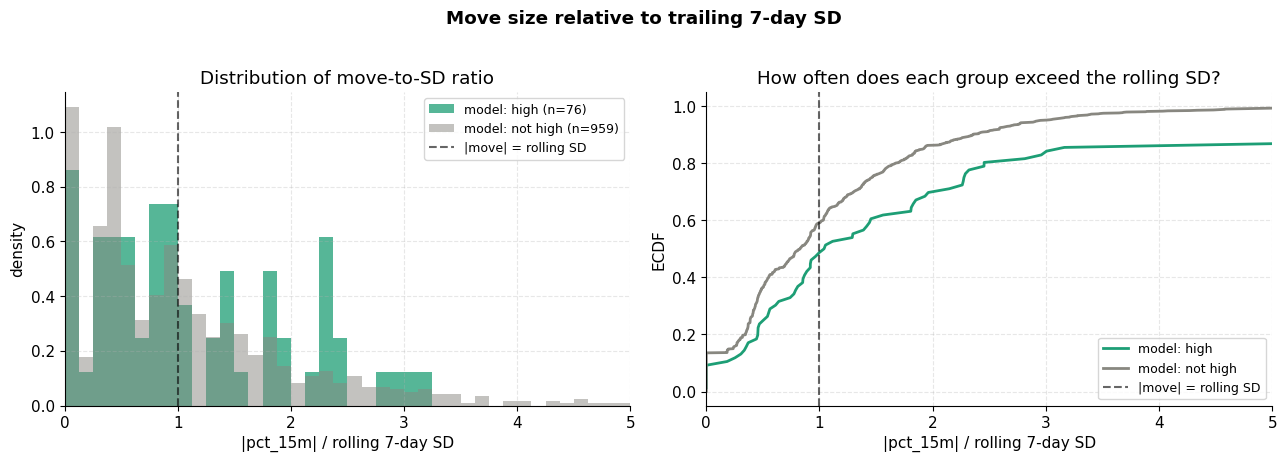


P(|move| > rolling SD | model high)     : 51.3%
P(|move| > rolling SD | model not high) : 41.0%
Lift                                    : 1.25×


In [5]:
ratio = eligible["pct_15m"].abs() / eligible["rolling_sd_15m"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histograms
ax = axes[0]
bins = np.linspace(0, 5, 41)
ax.hist(ratio[eligible["model_high"]],  bins=bins, alpha=0.75, color=TEAL,
        label=f"model: high (n={eligible['model_high'].sum()})", density=True)
ax.hist(ratio[~eligible["model_high"]], bins=bins, alpha=0.5, color=GRAY,
        label=f"model: not high (n={(~eligible['model_high']).sum()})", density=True)
ax.axvline(1.0, color="black", linestyle="--", alpha=0.6, label="|move| = rolling SD")
ax.set_xlabel("|pct_15m| / rolling 7-day SD")
ax.set_ylabel("density")
ax.set_title("Distribution of move-to-SD ratio")
ax.legend(fontsize=9)
ax.set_xlim(0, 5)

# ECDFs
ax2 = axes[1]
for label, mask, color in [
    ("model: high",     eligible["model_high"],  TEAL),
    ("model: not high", ~eligible["model_high"], GRAY),
]:
    vals = np.sort(ratio[mask].dropna().values)
    if len(vals) == 0:
        continue
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax2.plot(vals, ecdf, label=label, color=color, linewidth=2)
ax2.axvline(1.0, color="black", linestyle="--", alpha=0.6, label="|move| = rolling SD")
ax2.set_xlabel("|pct_15m| / rolling 7-day SD")
ax2.set_ylabel("ECDF")
ax2.set_xlim(0, 5)
ax2.set_title("How often does each group exceed the rolling SD?")
ax2.legend(fontsize=9)

plt.suptitle(f"Move size relative to trailing {ROLLING_DAYS}-day SD",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

p_high_over_sd = (ratio[eligible["model_high"]]  > 1).mean() * 100
p_not_over_sd  = (ratio[~eligible["model_high"]] > 1).mean() * 100
print(f"\nP(|move| > rolling SD | model high)     : {p_high_over_sd:.1f}%")
print(f"P(|move| > rolling SD | model not high) : {p_not_over_sd:.1f}%")
print(f"Lift                                    : {p_high_over_sd / p_not_over_sd:.2f}×")


In [6]:
# Sample disagreement cases
fp = eligible[ eligible["model_high"] & ~eligible["rolling_high_bool"]].copy()
fp["ratio"] = (fp["pct_15m"].abs() / fp["rolling_sd_15m"]).round(3)
fp_view = fp[["dt", "event_name", "pct_15m", "rolling_sd_15m", "ratio", "title"]] \
            .sort_values("ratio")
print(f"FALSE POSITIVES — model said high, |move| ≤ rolling SD  ({len(fp)} rows)")
display(fp_view.head(10))

fn_ = eligible[~eligible["model_high"] & eligible["rolling_high_bool"]].copy()
fn_["ratio"] = (fn_["pct_15m"].abs() / fn_["rolling_sd_15m"]).round(3)
fn_view = fn_[["dt", "event_name", "pct_15m", "rolling_sd_15m", "ratio", "title"]] \
            .sort_values("ratio", ascending=False)
print(f"\nFALSE NEGATIVES — model said not high, |move| > rolling SD  ({len(fn_)} rows)")
display(fn_view.head(10))


FALSE POSITIVES — model said high, |move| ≤ rolling SD  (37 rows)


,dt,event_name,pct_15m,rolling_sd_15m,ratio,title
1153,2025-09-17 21:24:00+00:00,Fed Rate Cut,0.000000,0.034681,0.000,Here are five key takeaways from the Fed's big...
699,2025-08-01 15:04:00+00:00,NFP/Jobs Miss,0.000000,0.054229,0.000,Here's where the jobs are in this slowing econ...
129,2025-10-29 10:42:00+00:00,Hawkish Pivot / Surprise,0.000000,0.022012,0.000,Gold pares gains after Fed Powell's comments d...
132,2025-12-10 19:01:00+00:00,Fed Rate Cut,0.000000,0.019751,0.000,"The Fed cut rates 3 times in 2025, but don’t b..."
1024,2025-08-25 04:17:00+00:00,Dovish Pivot / Surprise,0.000000,0.035428,0.000,Dollar struggles to recover from dovish Powell...
422,2026-02-11 12:58:00+00:00,NFP/Jobs Beat,0.000000,0.022740,0.000,"January's jobs report, Ford earnings, Epstein ..."
218,2025-10-29 21:48:00+00:00,Fed Rate Path Repricing,0.000000,0.028235,0.000,Here are the five key takeaways from the Fed m...
477,2025-08-04 17:59:00+00:00,NFP/Jobs Miss,-0.010129,0.055134,0.184,Contentious July jobs report confirms the U.S....
433,2026-03-10 11:40:00+00:00,Risk-Off Shock,-0.010136,0.039869,0.254,"As Iran war disrupts oil prices, consumers cou..."
790,2025-08-01 04:30:00+00:00,NFP/Jobs Miss,-0.009995,0.032658,0.306,Gold rises 2% as US payrolls data boosts rate ...



FALSE NEGATIVES — model said not high, |move| > rolling SD  (393 rows)


,dt,event_name,pct_15m,rolling_sd_15m,ratio,title
52,2025-12-16 13:32:00+00:00,NFP/Jobs Miss,0.224650,0.023668,9.492,"Payrolls rose by 64,000 in November after fall..."
827,2025-09-11 12:16:00+00:00,Foreign Central Bank Shock,-0.183673,0.025801,7.119,European Central Bank leaves rates unchanged a...
622,2026-02-24 06:59:00+00:00,Trade Tariff / Policy Shock,0.143164,0.024665,5.804,European stocks finish higher as Trump's tarif...
595,2025-08-12 12:31:00+00:00,CPI/PCE Below Consensus,-0.152439,0.026838,5.680,"Consumer prices rise 2.7% annually in July, le..."
532,2026-03-04 10:01:00+00:00,Trade Tariff / Policy Shock,-0.181818,0.032444,5.604,'No to war’: Spain PM hits back at Trump threa...
767,2025-08-01 19:30:00+00:00,Executive Policy Signal,-0.282800,0.055149,5.128,"Fed Governor Kugler is resigning, giving Trump..."
128,2025-12-10 19:00:00+00:00,Irrelevant,-0.101041,0.019727,5.122,What December's Fed rate cut means for your mo...
1031,2025-09-29 08:12:00+00:00,Other / Mixed,0.112360,0.022500,4.994,Treasury yields slide as investors look ahead ...
664,2025-09-02 12:05:00+00:00,Irrelevant,0.122075,0.025384,4.809,Russia clinches major new gas pipeline deal wi...
676,2025-08-14 12:20:00+00:00,Executive Policy Signal,0.132843,0.028237,4.705,Economist Sumerlin confirms he's in the runnin...


---
## 4 — Rolling SD vs the global SD threshold

`eval_signal_v2.ipynb` evaluates against a single global SD computed across
the whole eval window. How different is that threshold, and how often do
the two thresholds flag the same row as "big"?


In [7]:
global_sd_15m = eligible["pct_15m"].std()
eligible["global_high_bool"] = eligible["pct_15m"].abs() > global_sd_15m

print(f"Global SD (one number across whole window) : {global_sd_15m:.4f}%")
print(f"Median 7-day rolling SD                    : {eligible['rolling_sd_15m'].median():.4f}%")
print(f"Min / Max rolling SD                       : "
      f"{eligible['rolling_sd_15m'].min():.4f}% / {eligible['rolling_sd_15m'].max():.4f}%")
print(f"  → ratio (median rolling / global)        : "
      f"{eligible['rolling_sd_15m'].median() / global_sd_15m:.2f}×")

cm_g_vs_r = pd.crosstab(
    eligible["global_high_bool"].map({True: "global: high", False: "global: not high"}),
    eligible["rolling_high_bool"].map({True: "rolling: high", False: "rolling: not high"}),
    margins=True, margins_name="total",
)
print("\nWhich rows do the two thresholds disagree on?")
display(cm_g_vs_r)


Global SD (one number across whole window) : 0.0622%
Median 7-day rolling SD                    : 0.0266%
Min / Max rolling SD                       : 0.0173% / 0.0553%
  → ratio (median rolling / global)        : 0.43×

Which rows do the two thresholds disagree on?


rolling_high_bool,rolling: high,rolling: not high,total
global_high_bool,,,
global: high,120,0,120
global: not high,312,603,915
total,432,603,1035


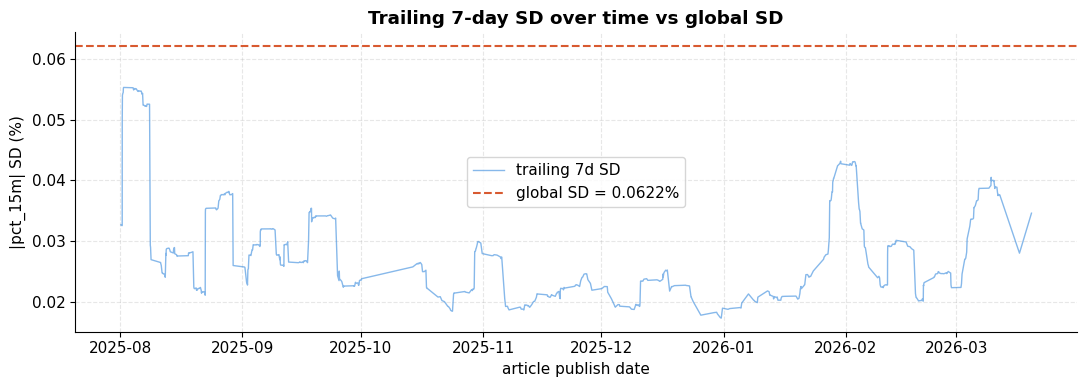

In [8]:
# Plot the rolling SD over time, with the global SD as a horizontal reference
plot_df = eligible.dropna(subset=["rolling_sd_15m"]).sort_values("dt")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(plot_df["dt"], plot_df["rolling_sd_15m"], color=BLUE, alpha=0.6,
        linewidth=1, label=f"trailing {ROLLING_DAYS}d SD")
ax.axhline(global_sd_15m, color=CORAL, linestyle="--", linewidth=1.5,
           label=f"global SD = {global_sd_15m:.4f}%")
ax.set_ylabel("|pct_15m| SD (%)")
ax.set_xlabel("article publish date")
ax.set_title(f"Trailing {ROLLING_DAYS}-day SD over time vs global SD",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 5 — Volatility lift under each label

Replicates Section 1 of `eval_signal_v2.ipynb` but separately for the two
"high" definitions, so it's clear which label is more discriminating across
horizons.


In [9]:
HORIZONS = ["pct_5m", "pct_15m", "pct_1h", "pct_4h", "pct_1d"]
H_LABELS = ["5m", "15m", "1h", "4h", "1d"]

eligible["model_label"] = np.where(eligible["model_high"], "high", "not high")

def lift_table(label_col, name):
    rows = []
    high_grp = eligible[eligible[label_col] == "high"]
    nh_grp   = eligible[eligible[label_col] == "not high"]
    for h, hl in zip(HORIZONS, H_LABELS):
        hv  = high_grp[h].dropna().abs()
        nhv = nh_grp[h].dropna().abs()
        if len(hv) == 0 or len(nhv) == 0:
            continue
        _, p = mannwhitneyu(hv, nhv, alternative="greater")
        rows.append({
            "horizon":         hl,
            "n high":          len(hv),
            "n not-high":      len(nhv),
            "mean |high|":     f"{hv.mean():.4f}%",
            "mean |not-high|": f"{nhv.mean():.4f}%",
            "lift":            f"{hv.mean() / nhv.mean():.2f}×",
            "p-value":         f"{p:.4f}",
        })
    print(f"── {name}")
    display(pd.DataFrame(rows).set_index("horizon"))

lift_table("model_label",  "Model criticality (eval_signal_v2 baseline)")
print()
lift_table("rolling_high", f"Rolling {ROLLING_DAYS}-day SD criticality")


── Model criticality (eval_signal_v2 baseline)


,n high,n not-high,mean |high|,mean |not-high|,lift,p-value
horizon,,,,,,
5m,76,959,0.0492%,0.0175%,2.82×,0.0034
15m,76,959,0.0781%,0.0300%,2.60×,0.0007
1h,74,946,0.1443%,0.0597%,2.42×,0.0000
4h,70,877,0.2219%,0.1208%,1.84×,0.0001
1d,54,759,0.3434%,0.2695%,1.27×,0.0098



── Rolling 7-day SD criticality


,n high,n not-high,mean |high|,mean |not-high|,lift,p-value
horizon,,,,,,
5m,432,603,0.0283%,0.0137%,2.07×,0.0000
15m,432,603,0.0616%,0.0134%,4.58×,0.0000
1h,431,589,0.0847%,0.0521%,1.63×,0.0000
4h,415,532,0.1459%,0.1145%,1.27×,0.0010
1d,340,473,0.2740%,0.2747%,1.00×,0.5202


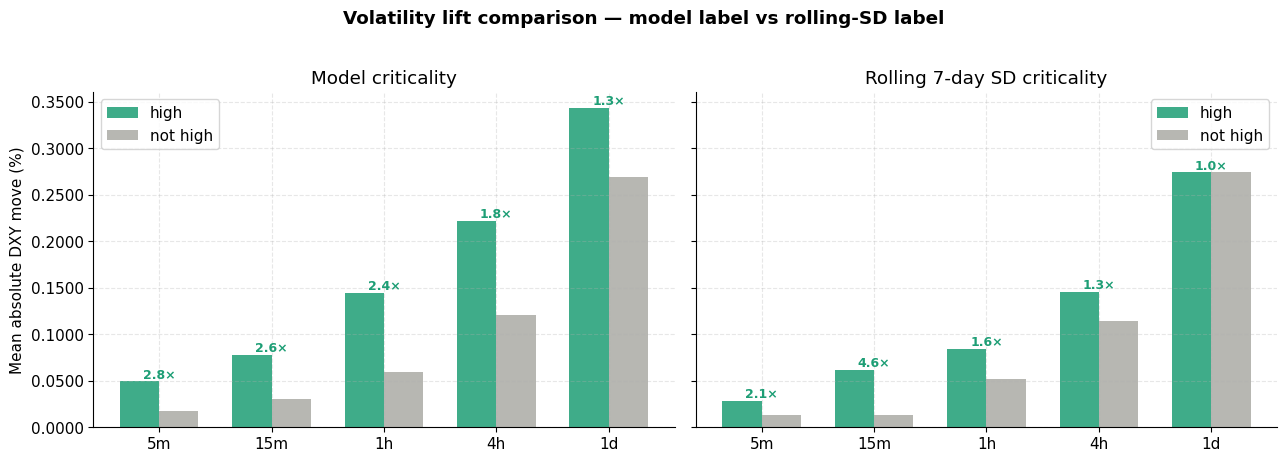

In [10]:
# Side-by-side bar chart of mean |move| by horizon, both labelings
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, label_col, title in [
    (axes[0], "model_label",  "Model criticality"),
    (axes[1], "rolling_high", f"Rolling {ROLLING_DAYS}-day SD criticality"),
]:
    high_grp = eligible[eligible[label_col] == "high"]
    nh_grp   = eligible[eligible[label_col] == "not high"]
    h_means  = [high_grp[h].abs().mean() for h in HORIZONS]
    nh_means = [nh_grp[h].abs().mean()   for h in HORIZONS]

    x = np.arange(len(HORIZONS))
    w = 0.35
    ax.bar(x - w/2, h_means,  w, label="high",     color=TEAL, alpha=0.85)
    ax.bar(x + w/2, nh_means, w, label="not high", color=GRAY, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(H_LABELS)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.4f}"))
    for i, (hm, nhm) in enumerate(zip(h_means, nh_means)):
        if nhm > 0:
            ax.text(i, hm + 0.00005, f"{hm/nhm:.1f}×", ha="center", va="bottom",
                    fontsize=9, color=TEAL, fontweight="bold")
    ax.legend()

axes[0].set_ylabel("Mean absolute DXY move (%)")
plt.suptitle("Volatility lift comparison — model label vs rolling-SD label",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## Headline


In [11]:
print("═" * 64)
print(f"  MODEL CRITICALITY vs {ROLLING_DAYS}-DAY ROLLING SD")
print("═" * 64)
print(f"  Eligible articles            : {len(eligible):,}")
print(f"  Model says high              : {eligible['model_high'].sum():4d}  "
      f"({eligible['model_high'].mean()*100:.1f}%)")
print(f"  Rolling SD says high         : {eligible['rolling_high_bool'].sum():4d}  "
      f"({eligible['rolling_high_bool'].mean()*100:.1f}%)")
print()
print("  Model performance vs rolling-SD ground truth:")
print(f"    precision                  : {precision*100:5.1f}%   ({TP}/{TP+FP})")
print(f"    recall                     : {recall*100:5.1f}%   ({TP}/{TP+FN})")
print(f"    F1                         : {f1:.3f}")
print(f"    accuracy                   : {accuracy*100:5.1f}%")
print(f"    base rate (rolling-high)   : {base_rate*100:5.1f}%")
print(f"    precision lift over base   : {precision/base_rate:.2f}×")
print("═" * 64)


════════════════════════════════════════════════════════════════
  MODEL CRITICALITY vs 7-DAY ROLLING SD
════════════════════════════════════════════════════════════════
  Eligible articles            : 1,035
  Model says high              :   76  (7.3%)
  Rolling SD says high         :  432  (41.7%)

  Model performance vs rolling-SD ground truth:
    precision                  :  51.3%   (39/76)
    recall                     :   9.0%   (39/432)
    F1                         : 0.154
    accuracy                   :  58.5%
    base rate (rolling-high)   :  41.7%
    precision lift over base   : 1.23×
════════════════════════════════════════════════════════════════
